In [51]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant

price_data = pd.read_csv("../data/prices.csv", index_col = 0, parse_dates = True).dropna()
price_data.head()

,AAPL,AMD,BAC,CVX,JPM,KO,MSFT,NVDA,PEP,XOM
Date,,,,,,,,,,
2023-01-03,123.096024,64.019997,30.974270,151.901291,124.928711,57.519154,233.452820,14.300685,162.498108,95.434189
2023-01-04,124.365662,64.660004,31.556595,150.286133,126.093643,57.491737,223.240829,14.734250,162.099548,95.711967
2023-01-05,123.046814,62.330002,31.491901,152.992584,126.065750,56.833855,216.624466,14.250736,160.405838,97.853439
2023-01-06,127.574188,63.959999,31.806168,154.145020,128.478058,57.930328,219.177444,14.844140,164.028809,99.036171
2023-01-09,128.095840,67.239998,31.325510,152.940186,127.947151,57.208481,221.311462,15.612370,162.425613,97.190392


In [52]:
# Split data 
split_idx = int(len(price_data) * 0.5) # splitting directly in half
split_date = price_data.index[split_idx] # ignoring the split date as it would be included in both

train = price_data.loc[:split_date]
test = price_data.loc[split_date:]
train.head()

,AAPL,AMD,BAC,CVX,JPM,KO,MSFT,NVDA,PEP,XOM
Date,,,,,,,,,,
2023-01-03,123.096024,64.019997,30.974270,151.901291,124.928711,57.519154,233.452820,14.300685,162.498108,95.434189
2023-01-04,124.365662,64.660004,31.556595,150.286133,126.093643,57.491737,223.240829,14.734250,162.099548,95.711967
2023-01-05,123.046814,62.330002,31.491901,152.992584,126.065750,56.833855,216.624466,14.250736,160.405838,97.853439
2023-01-06,127.574188,63.959999,31.806168,154.145020,128.478058,57.930328,219.177444,14.844140,164.028809,99.036171
2023-01-09,128.095840,67.239998,31.325510,152.940186,127.947151,57.208481,221.311462,15.612370,162.425613,97.190392


In [53]:
# Backtest function
def backtest_pair(price_data, t1, t2, window, entry_z, cost=0.0005):

    x = np.log(price_data[t1])
    y = np.log(price_data[t2])

    X = add_constant(x)
    beta = OLS(y, X).fit().params[1]

    spread = y - beta * x

    mean = spread.rolling(window).mean()
    std = spread.rolling(window).std().replace(0, np.nan)
    zscore = (spread - mean) / std

    position = pd.Series(0, index=spread.index)
    position[zscore > entry_z] = -1
    position[zscore < -entry_z] = 1
    position = position.ffill().fillna(0)

    ret_x = x.diff()
    ret_y = y.diff()
    spread_ret = ret_y - beta * ret_x

    strategy_ret = position.shift(1) * spread_ret

    trades = position.diff().abs()
    strategy_ret -= trades.shift(1) * cost

    strategy_ret = strategy_ret.dropna()

    if strategy_ret.std() == 0:
        return 0

    sharpe = strategy_ret.mean() / strategy_ret.std() * np.sqrt(252)

    return sharpe

In [54]:
# Run a Grid Search on the training data only

windows = [15,20,26,35,50]
thresholds = [1.5, 2.0, 2.5, 3.0]

t1 = "XOM"
t2 = "CVX"

results = []

for w in windows:
    for z in thresholds:
        sharpe = backtest_pair(train, t1, t2, w, z)
        results.append((w,z,sharpe))

results_df = pd.DataFrame(results, columns = ["Window", "Entry_Z", "Sharpe"])
results_df = results_df.sort_values(by = "Sharpe", ascending = False)

print("In-Sample results")
print(results_df)



C:\Users\yogst\AppData\Local\Temp\ipykernel_31160\3774291272.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = OLS(y, X).fit().params[1]
C:\Users\yogst\AppData\Local\Temp\ipykernel_31160\3774291272.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = OLS(y, X).fit().params[1]
C:\Users\yogst\AppData\Local\Temp\ipykernel_31160\3774291272.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = OLS(y, X).fit().params[1

In-Sample results
    Window  Entry_Z    Sharpe
11      26      3.0  1.013901
14      35      2.5  0.951780
7       20      3.0  0.760015
18      50      2.5  0.558654
1       15      2.0  0.488076
15      35      3.0  0.461678
16      50      1.5  0.412656
19      50      3.0  0.345883
3       15      3.0  0.000000
6       20      2.5 -0.047116
8       26      1.5 -0.059011
0       15      1.5 -0.116560
4       20      1.5 -0.118948
12      35      1.5 -0.201503
17      50      2.0 -0.217795
13      35      2.0 -0.224462
10      26      2.5 -0.226350
2       15      2.5 -0.740292
5       20      2.0 -0.802574
9       26      2.0 -0.863039


C:\Users\yogst\AppData\Local\Temp\ipykernel_31160\3774291272.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = OLS(y, X).fit().params[1]
C:\Users\yogst\AppData\Local\Temp\ipykernel_31160\3774291272.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = OLS(y, X).fit().params[1]
C:\Users\yogst\AppData\Local\Temp\ipykernel_31160\3774291272.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = OLS(y, X).fit().params[1

In [55]:
# Selecting best parameters
best_window = results_df.iloc[0]["Window"]
best_z = results_df.iloc[0]["Entry_Z"]

print("Best Parameters:")
print("Window:", best_window)
print("Entry Z:", best_z)

Best Parameters:
Window: 26.0
Entry Z: 3.0


In [56]:
# Out of Sample test
test_sharpe = backtest_pair(test, t1, t2, int(best_window), best_z)
# testing sharpe using best parameters from training data

print("Out-of-sample Sharpe:", test_sharpe)

Out-of-sample Sharpe: 0.5417135981588835


C:\Users\yogst\AppData\Local\Temp\ipykernel_31160\3774291272.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = OLS(y, X).fit().params[1]


Note that both sharpe values are quite low suggesting not profitable to trade 

In [57]:
# Equity Curve function
def equity_curve(price_data, t1, t2, window, entry_z, cost=0.0005):
    x = np.log(price_data[t1])
    y = np.log(price_data[t2])

    X = add_constant(x)
    model = OLS(y, X).fit()
    beta = model.params[1]

    spread = y - beta * x

    mean = spread.rolling(window).mean()
    std = spread.rolling(window).std()
    zscore = (spread - mean) / std

    position = pd.Series(0, index=spread.index)
    position[zscore > entry_z] = -1
    position[zscore < -entry_z] = 1
    position = position.ffill().fillna(0)

    spread_ret = spread.diff()
    strategy_ret = position.shift(1) * spread_ret

    trades = position.diff().abs()
    strategy_ret = strategy_ret - trades * cost

    equity = (1 + strategy_ret.fillna(0)).cumprod() # cumprod() returns a dataframe with cumulative product for each row

    return equity

C:\Users\yogst\AppData\Local\Temp\ipykernel_31160\56910674.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


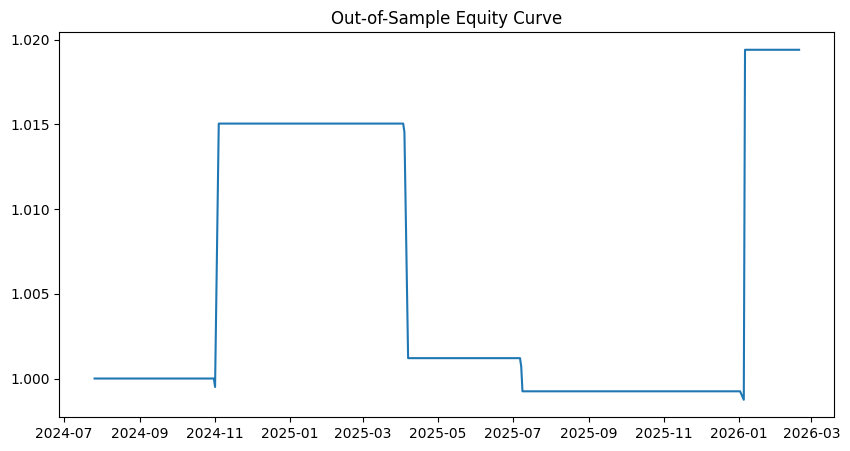

In [58]:
# Plot equity curve

equity = equity_curve(test, t1, t2, int(best_window), best_z)

plt.figure(figsize=(10,5))
plt.plot(equity)
plt.title("Out-of-Sample Equity Curve")
plt.show()